# Geometric Approaches: Inverse Perspective Mapping

**Imports**

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import yaml
import sys
sys.path.append("/kaggle/input/front-test/geometric/geometric/")
from utils import Plane, meshgrid, bilinear_sampler, perspective
import os

**Load a Rectified Image from the KITTI Dataset**

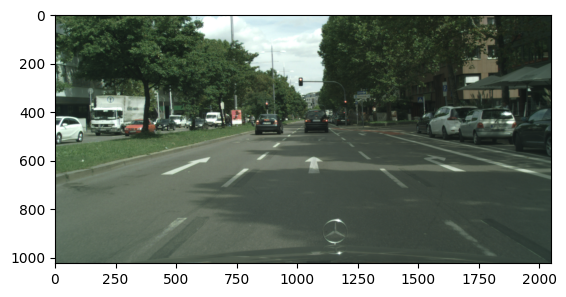

In [45]:
#TODO: Load the Stuttgart Image from the Geometric > Geometric > Folder file
path = "/kaggle/input/front-test/geometric/geometric/other/stuttgart_01_000000_003715_leftImg8bit.png"
image = cv2.imread(path, cv2.COLOR_BGR2RGB)
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

plt.imshow(image)
plt.show()

In [46]:
h, w, d = image.shape
w, h, d

(2048, 1024, 3)

### **IPM with 4 Points**

**Define 4 Points of Transformation**

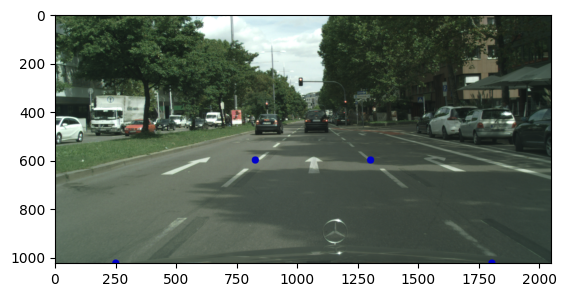

In [47]:
img = np.copy(image)
src_1 = (825, 600) #TODO: Define the top left point
src_2 = (250, h) #TODO: Define the bottom left point
src_3 = (1300, 600) #TODO: Defien the top right point
src_4 = (1800, h) #TODO: Define the bottom right point

cv2.circle(img, src_1, radius=15, color=(0,0,205),thickness=-1)
cv2.circle(img, src_2, radius=15, color=(0,0,205),thickness=-1)
cv2.circle(img, src_3, radius=15, color=(0,0,205),thickness=-1)
cv2.circle(img, src_4, radius=15, color=(0,0,205),thickness=-1)
plt.imshow(img)
plt.show()

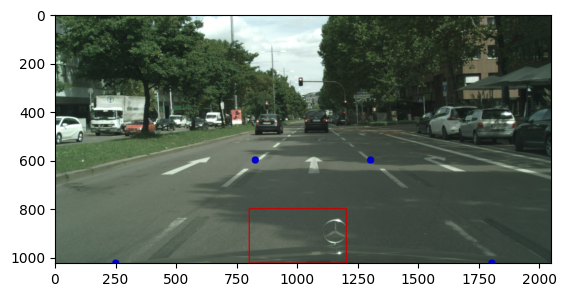

In [48]:
img2 = np.copy(img)

dst_1 = (800,800) #TODO: Define the top left point
dst_2 = (800,h) #TODO: Define the bottom left point
dst_3 = (1200,800) #TODO: Defien the top right point
dst_4 = (1200,h) #TODO: Define the bottom right point

cv2.rectangle(img2, dst_1, dst_4, (205,0,0),4)

plt.imshow(img2)
plt.show()

**Apply the Transformation**

In [49]:
src_points = np.array([src_1, src_2, src_3, src_4],dtype=np.float32)  # Original Region of Interest
dst_points = np.array([dst_1, dst_2, dst_3, dst_4],dtype=np.float32)   # Projected Rectangle

In [50]:
np.set_printoptions(precision=4, suppress=True)
M = cv2.getPerspectiveTransform(src_points, dst_points) #TODO: Call the perspective transform function from openCV
print(M)

[[  -0.3823   -2.4572 1426.5104]
 [   0.       -2.7214 1269.6123]
 [   0.       -0.0024    1.    ]]


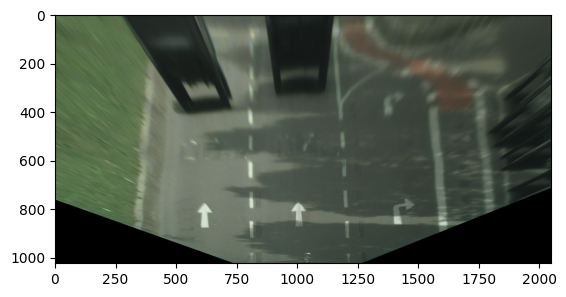

In [51]:
warped_img = cv2.warpPerspective(image, M, (w, h)) #TODO: Call the warp perspective function from openCV

plt.imshow(warped_img)
plt.show()

**This is done completely manually. A better alternative is to use the camera intrinsic and extrinsic calibration parameters**

## IPM with Parameters
Later in the course, you're going to apply IPM inside a Spatial Transformer Network. That part will be abstracted later on, but we WILL work on it right now.

First, we load a new image

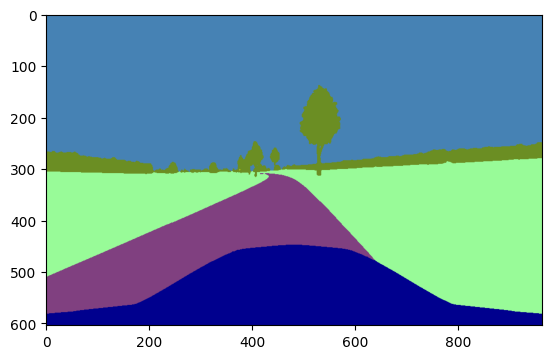

In [63]:
#TODO: Load a front image from the Geometric>Geometric>Front Dataset (ideally with no obstacles in front, like t_0_0_0001000.png)
filename= "/kaggle/input/front-test/geometric/geometric/front/t_0_0_0001000.png"
image = cv2.cvtColor(cv2.imread(filename), cv2.COLOR_BGR2RGB)
plt.imshow(image)
plt.show()

**Next, we load the camera parameters**.
To do this, we'll need:
* The intrinsic calibation matrix K
* The position of the camera
* The Yaw, Pitch, and Roll

In [64]:
with open("/kaggle/input/front-test/geometric/geometric/front/front.yaml") as stream:
    camConfig = yaml.safe_load(stream)
    
print(camConfig)

{'fx': 278.283, 'fy': 408.1295, 'px': 482.0, 'py': 302.0, 'yaw': 0.0, 'pitch': 0.0, 'roll': 0.0, 'XCam': 1.7, 'YCam': 0.0, 'ZCam': 1.4}


In [65]:
# camera calibration matrix K
fx= camConfig['fx'] #TODO: Pick from the config file
fy= camConfig['fy'] #TODO: Pick from the config file
px= camConfig['px'] #TODO: Pick from the config file
py= camConfig['py'] #TODO: Pick from the config file

# rotation matrix R (in deg)
yaw= camConfig['yaw'] #TODO: Pick from the config file
pitch= camConfig['pitch'] #TODO: Pick from the config file
roll= camConfig['roll'] #TODO: Pick from the config file

# vehicle coords of camera origin
XCam= camConfig['XCam'] #TODO: Pick from the config file
YCam= camConfig['YCam'] #TODO: Pick from the config file
ZCam= camConfig['ZCam'] #TODO: Pick from the config file

In [66]:
K = np.zeros([3, 3])
R = np.zeros([3, 3])
t = np.zeros([3, 1])
P = np.zeros([3, 4])

In [67]:
## Set K
K[0,0] = fx
K[1,1] = fy
K[0,2] = px
K[1,2] = py
K[2,2] = 1

K #TODO: Fill K with matrices from the config file


array([[278.283 ,   0.    , 482.    ],
       [  0.    , 408.1295, 302.    ],
       [  0.    ,   0.    ,   1.    ]])

In [68]:
y = np.deg2rad(yaw) 
p = np.deg2rad(pitch)
r = np.deg2rad(roll)

## Set R
Rx = np.array([
        [1, 0, 0],
        [0, np.cos(r), -np.sin(r)],
        [0, np.sin(r),  np.cos(r)]
    ])#TODO: Implement the matrix for Rz
Ry = np.array([
        [ np.cos(p), 0, np.sin(p)],
        [0, 1, 0],
        [-np.sin(p), 0, np.cos(p)]
    ])#TODO: Implement the matrix for Ry
Rz = np.array([
        [np.cos(y), -np.sin(y), 0],
        [np.sin(y),  np.cos(y), 0],
        [0, 0, 1]
    ])#TODO: Implement the matrix for Rx

#Rs = np.array([[0.0, -1.0, 0.0], [0.0, 0.0, -1.0], [1.0, 0.0, 0.0]]) # switch axes (x = -y, y = -z, z = x)
Rs = np.array([[0.0, 1.0, 0.0], [0.0, 0.0, -1.0], [1.0, 0.0, 0.0]]) # switch axes (x = -y, y = -z, z = x) #Additional R matrix

R = Rs @ Rz @ Ry @ Rx #TODO: R = Rs*(Rz*(Ry*Rx))

In [69]:
## Set T
X = np.array([XCam,YCam, ZCam])#Define X, an array with X, Y, Z cam
t = - R @ X #TODO: -R*X

In [70]:
## Update P
Rt = np.zeros([3, 4])
Rt[0:3, 0:3] = R
Rt[0:3, 3] = t
P = K @ Rt #TODO: Define P

In [71]:
print(np.round(K,1))
print(np.round(Rt,1))
print(np.round(P,1))

[[278.3   0.  482. ]
 [  0.  408.1 302. ]
 [  0.    0.    1. ]]
[[ 0.   1.   0.   0. ]
 [ 0.   0.  -1.   1.4]
 [ 1.   0.   0.  -1.7]]
[[ 482.   278.3    0.  -819.4]
 [ 302.     0.  -408.1   58. ]
 [   1.     0.     0.    -1.7]]


**Transform**

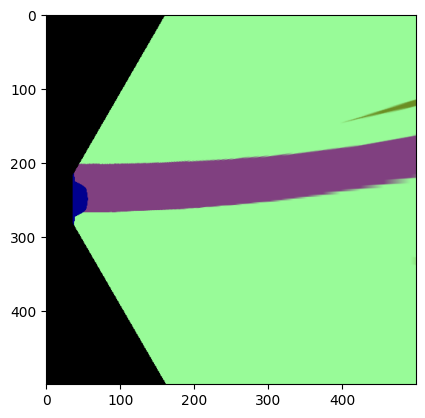

In [72]:
TARGET_W, TARGET_H = 500, 500 #TODO: Define the size of a plane

# get a set of points on a plane z=0, range from x = (0,100), y=(-50,50)
plane = Plane(0, -25, 0, 0, 0, 0, TARGET_H, TARGET_W, 0.1) 

# project 3d plane points on the 2d image plane
pixel_coords =  perspective(plane.xyz, P, TARGET_H, TARGET_W) #TODO: Call the perspective function

img_bev = bilinear_sampler(np.copy(image), pixel_coords) #TODO: Upsample the points
plt.imshow(img_bev.astype(int))
plt.show()

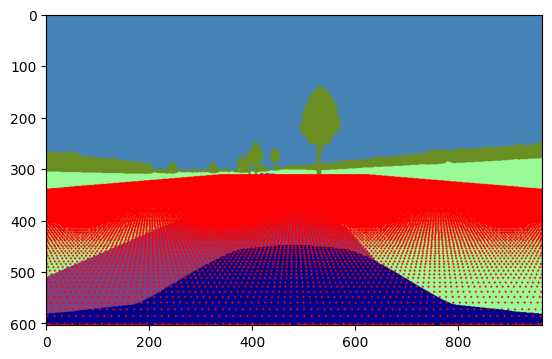

In [75]:
show_plane_pixels(np.copy(image), pixel_coords)

#### Try on other images? 
The other folders have their own camera parameters, and images.

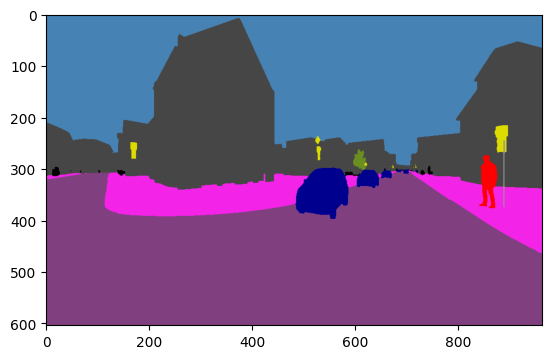

{'fx': 278.283, 'fy': 408.1295, 'px': 482.0, 'py': 302.0, 'yaw': 180.0, 'pitch': 0.0, 'roll': 0.0, 'XCam': -0.6, 'YCam': 0.0, 'ZCam': 1.4}


In [165]:
filename= '/kaggle/input/front-test/geometric/geometric/rear/rear.png'
image = cv2.cvtColor(cv2.imread(filename), cv2.COLOR_BGR2RGB)
plt.imshow(image)
plt.show()

with open("/kaggle/input/front-test/geometric/geometric/rear/rear.yaml") as stream:
    camConfig = yaml.safe_load(stream)
    
print(camConfig)

In [166]:
def get_parameters(camConfig):
    K = np.zeros([3, 3])
    R = np.zeros([3, 3])
    t = np.zeros([3, 1])
    P = np.zeros([3, 4])
    K[0, 0] = camConfig['fx']
    K[1, 1] = camConfig['fy']
    K[0, 2] = camConfig['px']
    K[1, 2] = camConfig['py']
    K[2, 2] = 1.0
    y = np.deg2rad(camConfig['yaw']) 
    p = np.deg2rad(camConfig['pitch'])
    r = np.deg2rad(camConfig['roll'])

    ## Set R
    Rz = np.array([[np.cos(-y), -np.sin(-y), 0.0], [np.sin(-y), np.cos(-y), 0.0], [0.0, 0.0, 1.0]])
    Ry = np.array([[np.cos(-p), 0.0, np.sin(-p)], [0.0, 1.0, 0.0], [-np.sin(-p), 0.0, np.cos(-p)]])
    Rx = np.array([[1.0, 0.0, 0.0], [0.0, np.cos(-r), -np.sin(-r)], [0.0, np.sin(-r), np.cos(-r)]])
    #Rs = np.array([[0.0, -1.0, 0.0], [0.0, 0.0, -1.0], [1.0, 0.0, 0.0]]) # switch axes (x = -y, y = -z, z = x)
    Rs = np.array([[0.0, 1.0, 0.0], [0.0, 0.0, -1.0], [1.0, 0.0, 0.0]]) # switch axes (x = y, y = -z, z = x)
    R = Rs.dot(Rz.dot(Ry.dot(Rx)))
        
    ## Set T
    X = np.array([camConfig['XCam'], camConfig['YCam'], camConfig['ZCam']])
    t = -R.dot(X)
    
    Rt = np.zeros([3, 4])
    Rt[0:3, 0:3] = R
    Rt[0:3, 3] = t
    P = K.dot(Rt)
    return P

P = get_parameters(camConfig)
print(np.round(P, 1))

[[-482.  -278.3    0.  -289.2]
 [-302.     0.  -408.1  390.2]
 [  -1.     0.     0.    -0.6]]


**Repeat the Projection Code**

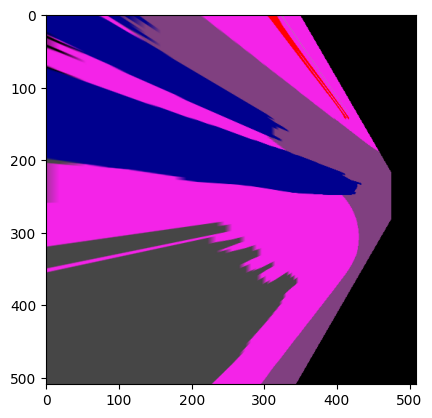

In [218]:
TARGET_W, TARGET_H = 509, 509
plane = Plane(-50, -25, -25, 0, 0, 0, TARGET_H, TARGET_W, 0.1)

pixel_coords = perspective(plane.xyz, P, TARGET_H, TARGET_W)
img_bev = bilinear_sampler(np.copy(image), pixel_coords)
plt.imshow(img_bev.astype(int))
plt.show()

<class 'numpy.ndarray'>


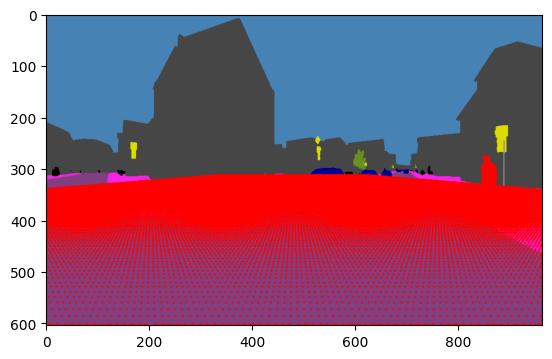

In [225]:
show_plane_pixels(np.copy(image), pixel_coords)

In [220]:
print(plane.xyz.shape)
print(pixel_coords.shape)

print(plane.xyz[:,0])
print(pixel_coords[0,0])

(4, 259081)
(509, 509, 2)
[-50. -25.   0.   1.]
[622.83147647 313.56642244]


In [221]:
print(image[0,0])
print(np.array(image)[0,0])

[ 70 130 180]
[ 70 130 180]


In [222]:
print(P)
pt = [-50,-25,0,1]
pix_homogenous = P @ pt
print(pix_homogenous)
pix = pix_homogenous[:2]/pix_homogenous[2]
print(pix)

[[-4.82000000e+02 -2.78283000e+02  0.00000000e+00 -2.89200000e+02]
 [-3.02000000e+02  3.69843333e-14 -4.08129500e+02  3.90181300e+02]
 [-1.00000000e+00  1.22464680e-16  0.00000000e+00 -6.00000000e-01]]
[30767.875  15490.1813    49.4   ]
[622.83147773 313.56642308]


# **Inverse Projections with Depth**

### Original Code

/tmp/ipykernel_34/4054381715.py:5: DeprecationWarning: Starting with ImageIO v3 the behavior of this function will switch to that of iio.v3.imread. To keep the current behavior (and make this warning disappear) use `import imageio.v2 as imageio` or call `imageio.v2.imread` directly.
  depth = imageio.imread("/kaggle/input/front-test/depth/depth/depth.exr")
/tmp/ipykernel_34/4054381715.py:8: DeprecationWarning: Starting with ImageIO v3 the behavior of this function will switch to that of iio.v3.imread. To keep the current behavior (and make this warning disappear) use `import imageio.v2 as imageio` or call `imageio.v2.imread` directly.
  image = imageio.imread("/kaggle/input/front-test/depth/depth/rgb.png")


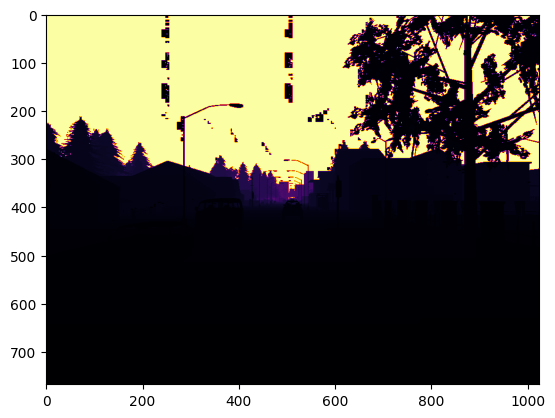

In [65]:
import imageio
imageio.plugins.freeimage.download()

# Load the Depth.EXR image from Depth > Depth
depth = imageio.imread("/kaggle/input/front-test/depth/depth/depth.exr")

# Load the RGB Image from Depth > Depth
image = imageio.imread("/kaggle/input/front-test/depth/depth/rgb.png")

plt.imshow(depth, cmap="inferno")
plt.show()

In [66]:
print(depth)

[[1000.     1000.     1000.     ...   13.9766   13.9609   14.1953]
 [1000.     1000.     1000.     ...   13.9922   13.9688   14.2109]
 [1000.     1000.     1000.     ...   14.0078   13.9844   13.9688]
 ...
 [   2.668     2.668     2.668  ...    2.5254    2.5254    2.5254]
 [   2.6602    2.6602    2.6602 ...    2.5195    2.5195    2.5195]
 [   2.6543    2.6543    2.6543 ...    2.5117    2.5117    2.5117]]


In [67]:
print(image.shape)
print(depth.shape)
height, width = depth.shape[:2]

(768, 1024, 4)
(768, 1024)


In [68]:
def intrinsic_from_fov(height, width, fov=90):
    """
    Basic Pinhole Camera Model
    intrinsic params from fov and sensor width and height in pixels
    Returns:
        K:      [4, 4]
    """     
    px, py = (width / 2, height / 2)
    hfov = fov / 360. * 2. * np.pi
    fx = width / (2. * np.tan(hfov / 2.))

    vfov = 2. * np.arctan(np.tan(hfov / 2) * height / width)
    fy = height / (2. * np.tan(vfov / 2.))

    return np.array([[fx, 0, px, 0.],
                     [0, fy, py, 0.],
                     [0, 0, 1., 0.],
                     [0., 0., 0., 1.]])

intrinsic = intrinsic_from_fov(height, width)

In [69]:
cam_coords = np.zeros((height * width, 3))

u0 = intrinsic[0, 2]
v0 = intrinsic[1, 2]
fx = intrinsic[0, 0]
fy = intrinsic[1, 1]
i = 0

# Loop through each pixel in the image
for v in range(height):
    for u in range(width):
        z = depth[v, u] # TODO: Define X
        x =  (u - u0) * z / fx # TODO: Define Y
        y = (v - v0) * z / fy # TODO: Define Z
        cam_coords[i] = (x, y, z)
        i += 1
cam_coords = cam_coords.T


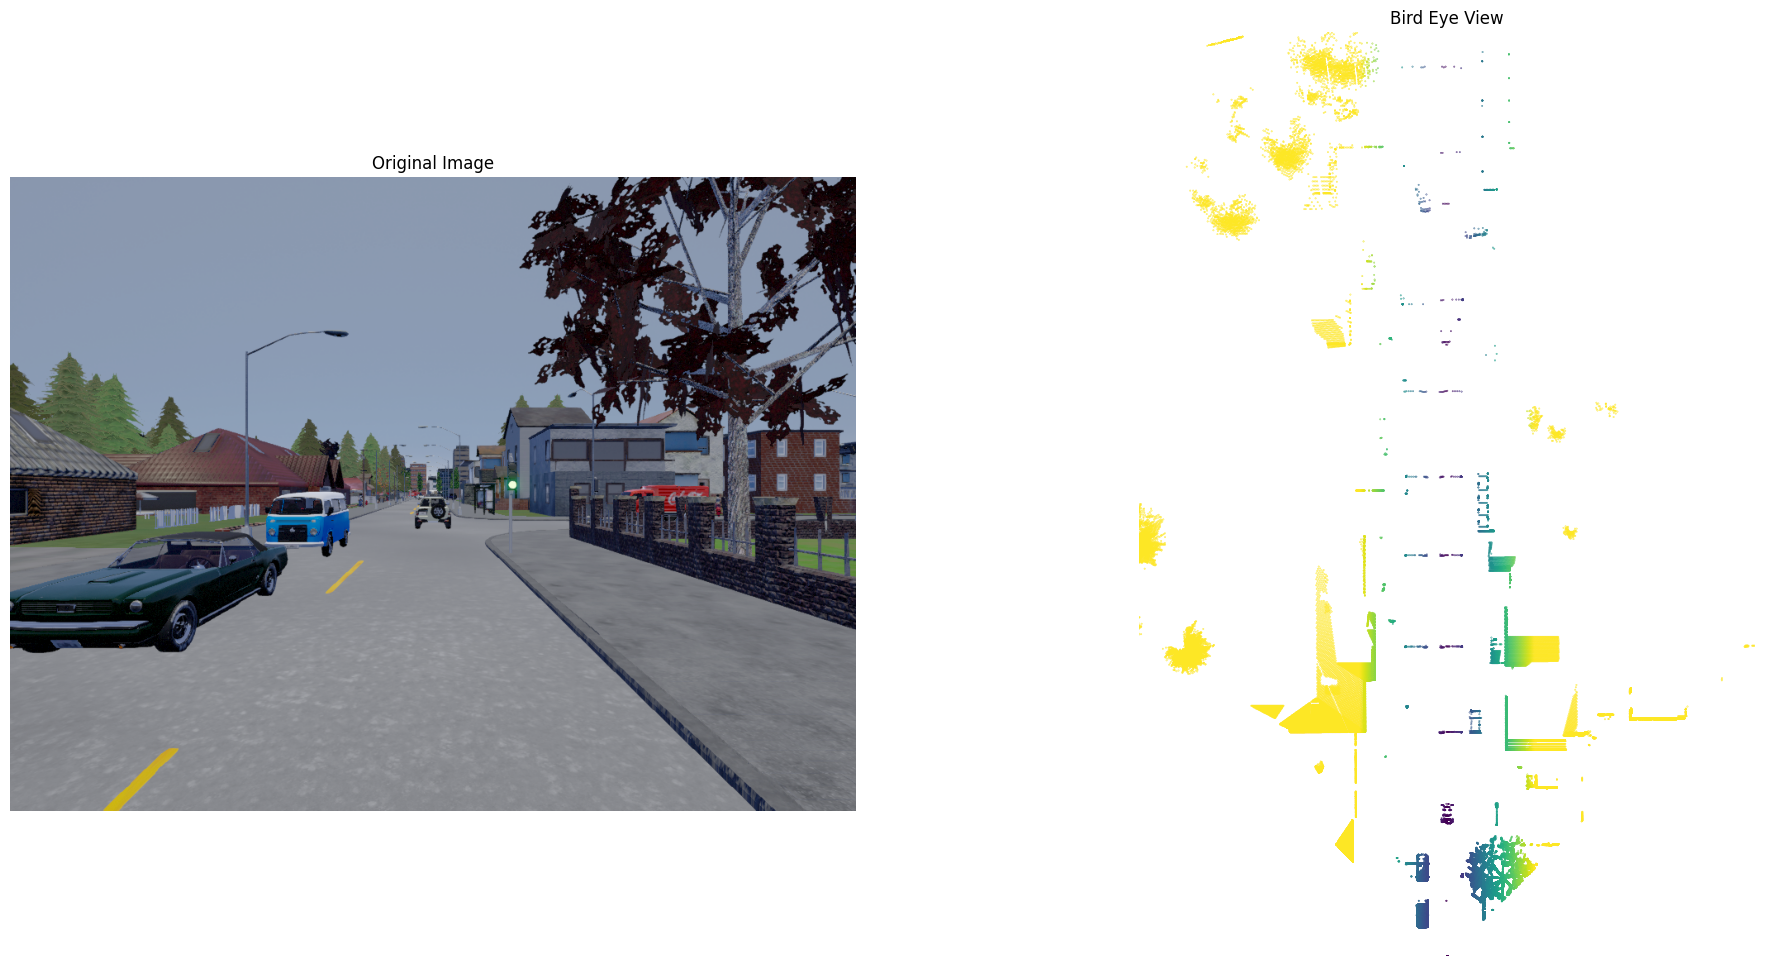

In [70]:
def project_depthmap(cam_points,rgb, cam_pos = -1.2):
    max_longitudinal = 150 #TODO: Define a Max Distance
    window_x = (-50, 50) #TODO: Define a Side Window
    window_y = (0,max_longitudinal) #TODO: Define a Range Window

    x, y, z = cam_points
    # flip the y-axis to positive upwards
    y = - y

    # We sample points for points less than 70m ahead and above ground
    # Camera is mounted 1m above on an ego vehicle
    ind = np.where((z < max_longitudinal) & (y > cam_pos))
    #ind = np.where(z < max_longitudinal)
    bird_eye = cam_points[:3, ind]

    # Color by pixels or radial distance
    dists = np.sqrt(np.sum(bird_eye[0:2:2, :] ** 2, axis=0))
    axes_limit = 10
    colors = np.minimum(1, dists / axes_limit / np.sqrt(2))
    fig, (ax0, ax1) = plt.subplots(1, 2, figsize=(24, 12))
    ax0.imshow(rgb)
    ax0.set_title("Original Image")
    ax0.axis("off")
    ax1.scatter(bird_eye[0, :], bird_eye[2, :], c=colors, s=0.1)
    ax1.set_xlim(window_x)
    ax1.set_ylim(window_y)
    ax1.set_title('Bird Eye View')
    plt.axis('off')

    plt.gca().set_aspect('equal')
    plt.show()

project_depthmap(cam_coords, image)

### KITTI Challenge

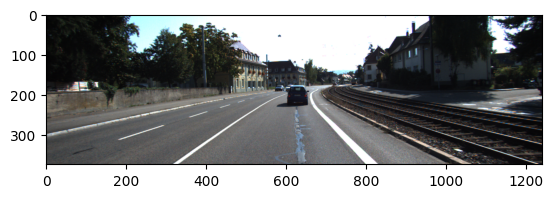

In [71]:
image = cv2.cvtColor(cv2.imread('/kaggle/input/front-test/depth/depth/KITTI/000009.png'), cv2.COLOR_BGR2RGB)
plt.imshow(image)
plt.show()

(375, 1242)


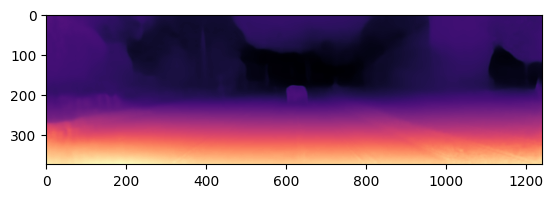

In [72]:
depth_raw = np.load("/kaggle/input/front-test/depth/depth/KITTI/depth_map_monodepth.npy")
print(depth_raw.shape)
plt.imshow(depth_raw, cmap="magma")

In [73]:
print(image.shape)
print(depth_raw.shape)
print((depth_raw))

(375, 1242, 3)
(375, 1242)
[[0.1692 0.1687 0.1678 ... 0.1274 0.1289 0.1297]
 [0.169  0.1685 0.1676 ... 0.1273 0.1287 0.1295]
 [0.1685 0.168  0.1672 ... 0.127  0.1285 0.1293]
 ...
 [0.5753 0.575  0.5744 ... 0.5578 0.5606 0.5621]
 [0.5774 0.5771 0.5765 ... 0.5615 0.5644 0.566 ]
 [0.5785 0.5782 0.5776 ... 0.5634 0.5664 0.568 ]]


In [74]:
def disp_to_depth(disp, min_depth, max_depth): 
    '''
    Convert network's sigmoid output into depth prediction 
    The formula for this conversion is given in the 'additional considerations' 
    section of the paper. 
    ''' 
    min_disp = 1 / max_depth 
    max_disp = 1 / min_depth 
    scaled_disp = min_disp + (max_disp - min_disp) * disp 
    depth = 1 / scaled_disp 
    return scaled_disp, depth

scaled_disp, depth = disp_to_depth(depth_raw, 1e-3, 200)

In [75]:
print(np.max(scaled_disp))
print(np.max(depth))

598.7772
0.09318734


**Get the 3D values**

In [76]:
disp_resized = cv2.resize(depth, (1216, 352))
depth = 5.4 / disp_resized
depth = np.clip(depth, 0, 200)
#depth = np.uint16(depth * 256)

In [77]:
print(depth.shape)
print(np.max(depth))

(352, 1216)
200.0


In [78]:
height, width = depth.shape
intrinsic = intrinsic_from_fov(height, width)
print(intrinsic)

[[608.   0. 608.   0.]
 [  0. 608. 176.   0.]
 [  0.   0.   1.   0.]
 [  0.   0.   0.   1.]]


In [79]:
#Real KITTI Values
#K = [[721.5377   0.     609.5593]
 #[  0.     721.5377 172.854 ]
 #[  0.       0.       1.    ]]

In [80]:
cam_coords = np.zeros((height * width, 3))

u0 = intrinsic[0, 2] 
v0 = intrinsic[1, 2] 
fx = intrinsic[0, 0] 
fy = intrinsic[1, 1]
i = 0

# Loop through each pixel in the image
for v in range(height):
    for u in range(width):
        x = (u - u0) * depth[v, u] / fx
        y = (v - v0) * depth[v, u] / fy
        z = depth[v, u]
        cam_coords[i] = (x, y, z)
        i += 1
cam_coords = cam_coords.T

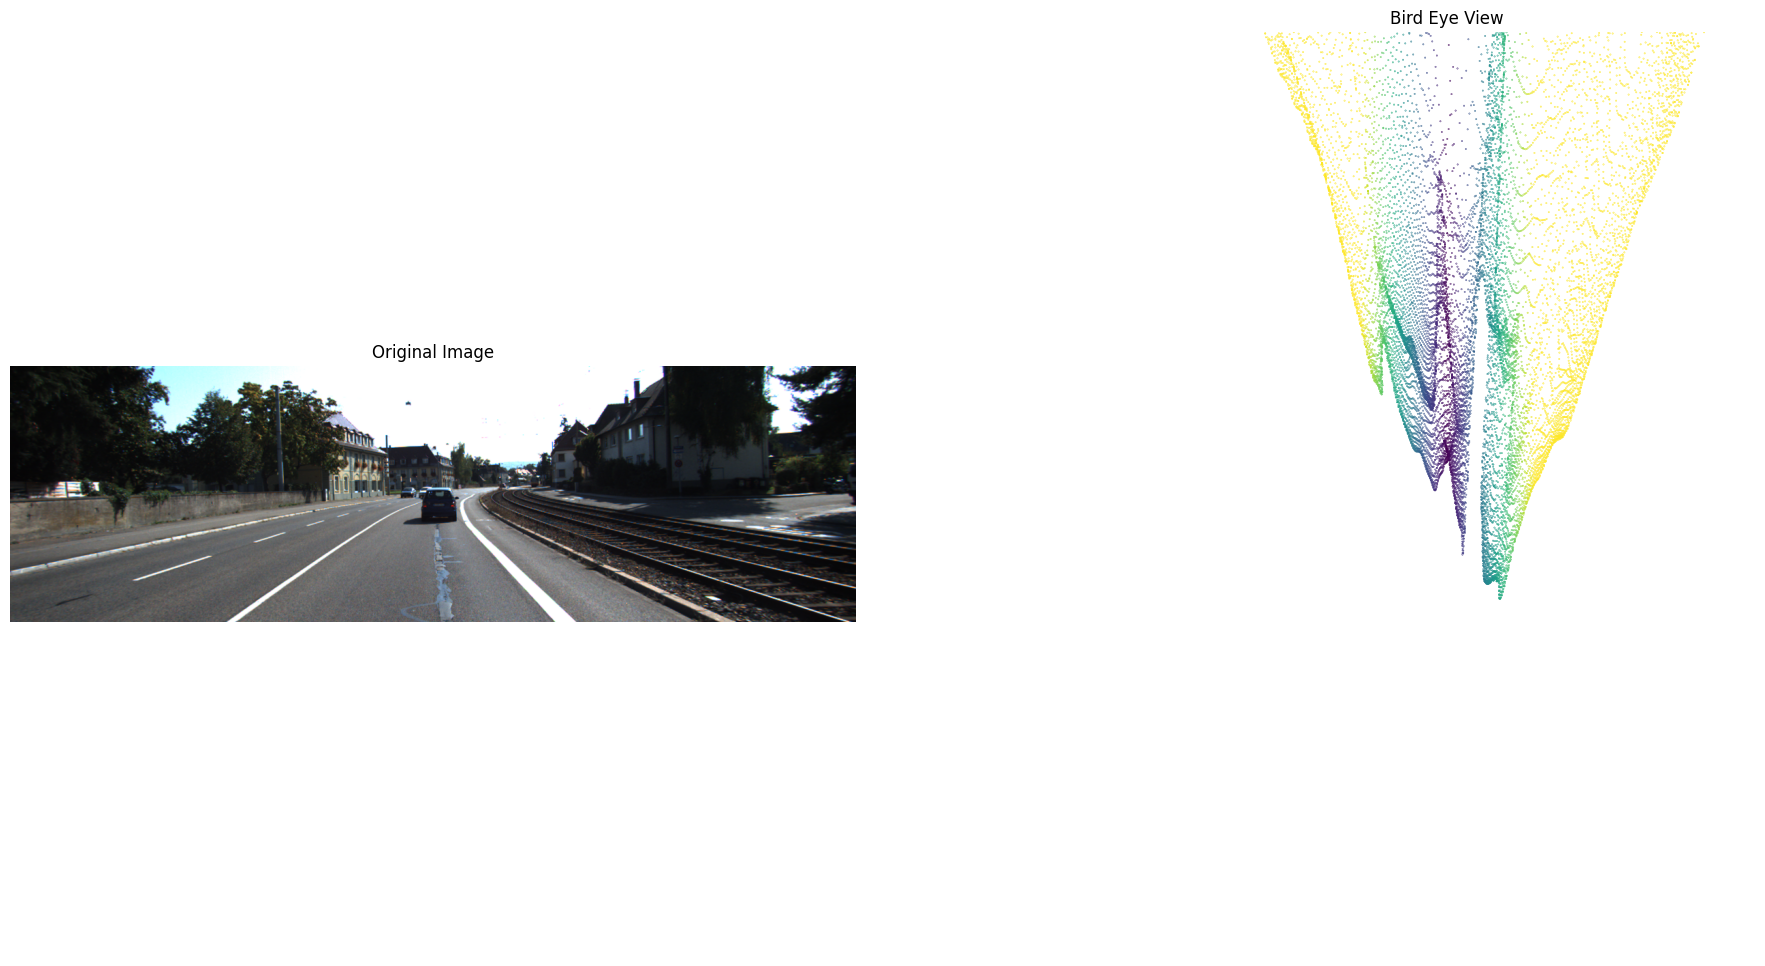

In [81]:
project_depthmap(cam_coords, image, cam_pos=-2)

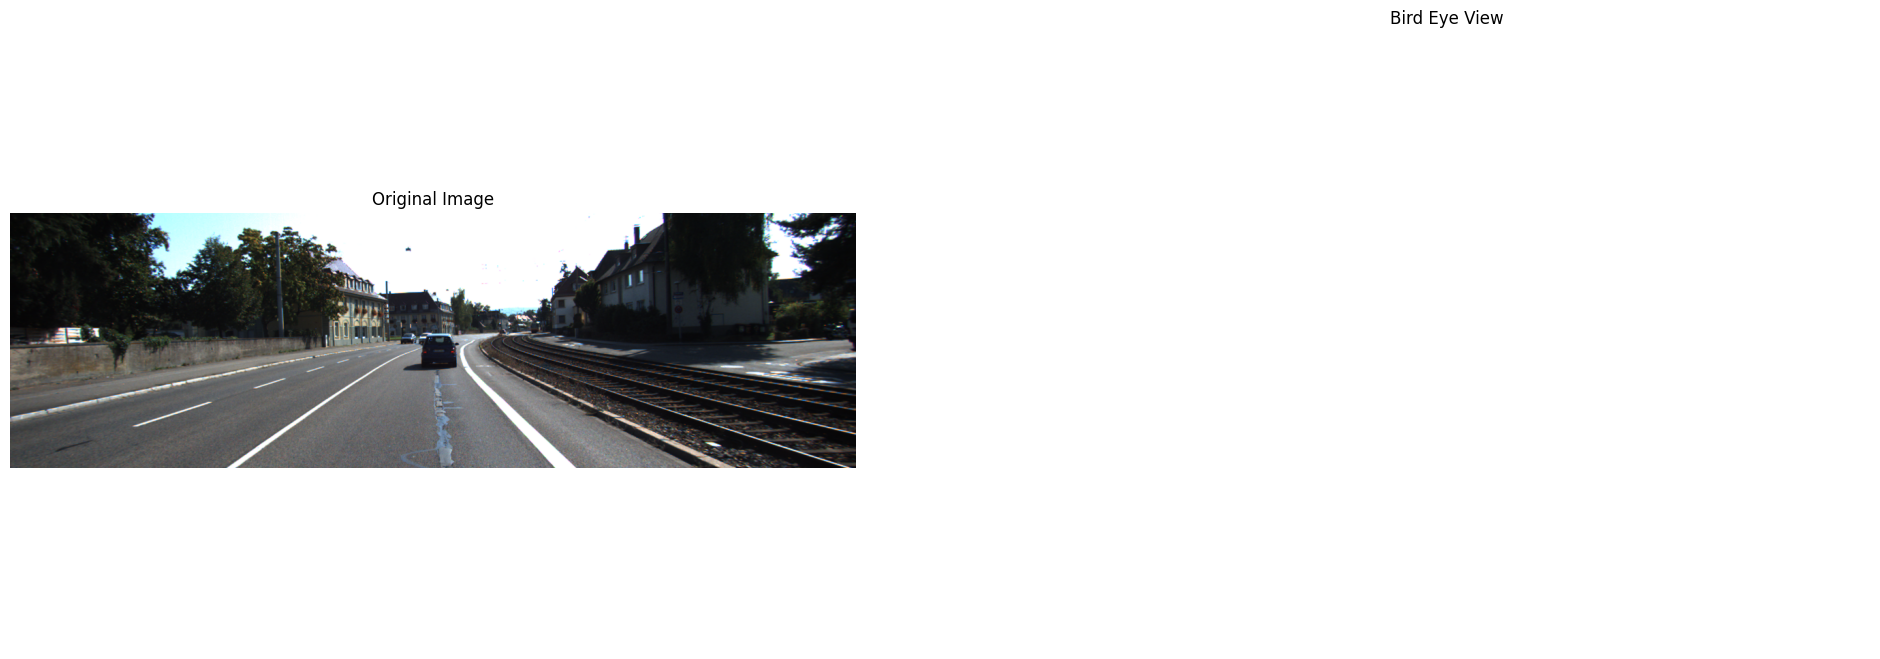

In [82]:
def project_topview(cam_points, rgb):
    """
    Draw the topview projection
    """
    max_longitudinal = 70
    window_x = (-50, 50)
    window_y = (-3, max_longitudinal)

    x, y, z = cam_points
    # flip the y-axis to positive upwards
    y = - y

    # We sample points for points less than 70m ahead and above ground
    # Camera is mounted 1m above on an ego vehicle
    ind = np.where((z < max_longitudinal) & (y > -1.2) & (y<2))
    #ind = np.where(z < max_longitudinal)

    bird_eye = cam_points[:3, ind]
    colors_rgb = rgb[cam_points[1].astype(int), cam_points[0].astype(int), :]
    filtered_colors = colors_rgb[ind[0]]/255.0

    # Color by pixels or radial distance
    fig, (ax0, ax1) = plt.subplots(1, 2, figsize=(24, 12))
    ax0.imshow(rgb)
    ax0.set_title("Original Image")
    ax0.axis("off")
    ax1.scatter(bird_eye[0, :], bird_eye[2, :], c=filtered_colors, s=0.1)
    ax1.set_xlim(window_x)
    ax1.set_ylim(window_y)
    ax1.set_title('Bird Eye View')
    plt.axis('off')

    plt.gca().set_aspect('equal')
    plt.show()


# Do top view projection
project_topview(cam_coords, image)

# Video of BEV with camera parameters

In [279]:
folder = '/kaggle/input/cam2bev-frlr/cam2bev/cam2bev-data-master/1_FRLR/train/front'
files = sorted([os.path.join(folder, f) for f in os.listdir(folder)])

In [280]:
camera_config_file = "/kaggle/input/front-test/geometric/geometric/front/front.yaml"
with open(camera_config_file) as stream:
    camConfig = yaml.safe_load(stream)

In [281]:
palette = np.array([
    [(128, 64, 128)],   # road
    [(244, 35, 232)],   # sidewalk
    [(70, 70, 70)],     # building
    [(107, 142, 35)],   # vegetation
    [(0, 0, 142)],      # car
    [(220, 20, 60)],    # person
    [(0, 0, 70)],       # truck
    [(0, 60, 100)],     # bus
    [(0, 80, 100)],     # train
    [(0, 0, 230)],      # motorcycle
])

def one_hot_decode_image(one_hot_image, palette):

    # create empty image with correct dimensions
    height, width = one_hot_image.shape[1:3]
    depth = palette[0][0].size
    image = np.zeros([height, width, depth])

    # reduce all layers of one-hot-encoding to one layer with indices of the classes
    map_of_classes = one_hot_image.argmax(0)

    for idx, class_colors in enumerate(palette):
        # fill image with corresponding class colors
        image[np.where(map_of_classes == idx)] = class_colors[0]

    image = image.astype(np.uint8)

    return image

def npy2img(file):
    arr = np.load(file)  # shape (C, H, W)
    rgb = one_hot_decode_image(arr, palette) #Pallet size is 10
    return rgb

In [282]:
def get_parameters(camConfig):
    K = np.zeros([3, 3])
    R = np.zeros([3, 3])
    t = np.zeros([3, 1])
    P = np.zeros([3, 4])
    K[0, 0] = camConfig['fx']
    K[1, 1] = camConfig['fy']
    K[0, 2] = 512/2
    K[1, 2] = 256/2
    K[2, 2] = 1.0
    print(K)
    y = np.deg2rad(camConfig['yaw']) 
    p = np.deg2rad(camConfig['pitch'])
    r = np.deg2rad(camConfig['roll'])

    ## Set R
    Rz = np.array([[np.cos(-y), -np.sin(-y), 0.0], [np.sin(-y), np.cos(-y), 0.0], [0.0, 0.0, 1.0]])
    Ry = np.array([[np.cos(-p), 0.0, np.sin(-p)], [0.0, 1.0, 0.0], [-np.sin(-p), 0.0, np.cos(-p)]])
    Rx = np.array([[1.0, 0.0, 0.0], [0.0, np.cos(-r), -np.sin(-r)], [0.0, np.sin(-r), np.cos(-r)]])
    Rs = np.array([[0.0, -1.0, 0.0], [0.0, 0.0, -1.0], [1.0, 0.0, 0.0]]) # switch axes (x = -y, y = -z, z = x)
    R = Rs.dot(Rz.dot(Ry.dot(Rx)))
        
    ## Set T
    X = np.array([camConfig['XCam'], camConfig['YCam'], camConfig['ZCam']])
    t = -R.dot(X)
    
    Rt = np.zeros([3, 4])
    Rt[0:3, 0:3] = R
    Rt[0:3, 3] = t
    P = K.dot(Rt)

    return P

In [283]:
def show_plane_pixels(img, pix):
    print(type(img))
    h, w = img.shape[:2]
    for row in pix:
        # mid = int(len(row)/2)
        # u, v = row[mid]
        for pt in row:
            u, v = pt
            u = np.clip(u, 0, w).astype(int)
            v = np.clip(v, 0, h).astype(int)
            # print(pt)
            # print(x,y)
            cv2.circle(img, (u, v), radius=2, color=(255, 0, 0), thickness=-1)  # red filled circle
    plt.imshow(img, origin='upper')

[[278.283    0.     256.    ]
 [  0.     408.1295 128.    ]
 [  0.       0.       1.    ]]
<class 'numpy.ndarray'>


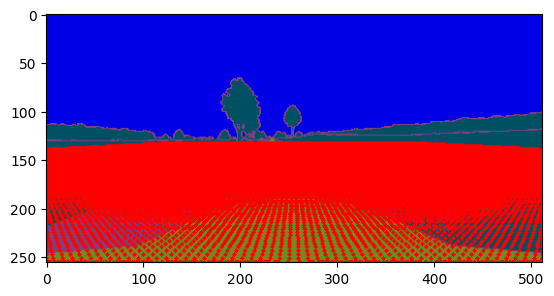

In [284]:
P = get_parameters(camConfig)
plane = Plane(5, -40, 0, 0, 0, 0, 500, 500, 0.16) 
first = npy2img(files[0])
pix = perspective(plane.xyz, P, plane.col, plane.row)
bev = bilinear_sampler(np.copy(first), pix)

show_plane_pixels(np.copy(first),pix)

In [285]:
print(P)
pt = [4,0,0,1]
pix_homogenous = P @ pt
print(pix_homogenous)
pix = pix_homogenous[:2]/pix_homogenous[2]
print(pix)

[[ 256.     -278.283     0.     -435.2   ]
 [ 128.        0.     -408.1295  353.7813]
 [   1.        0.        0.       -1.7   ]]
[588.8    865.7813   2.3   ]
[256.         376.42665217]


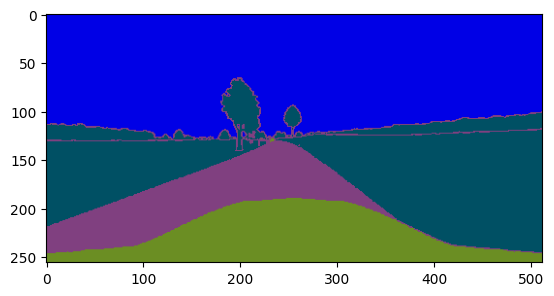

In [286]:
plt.imshow(first)

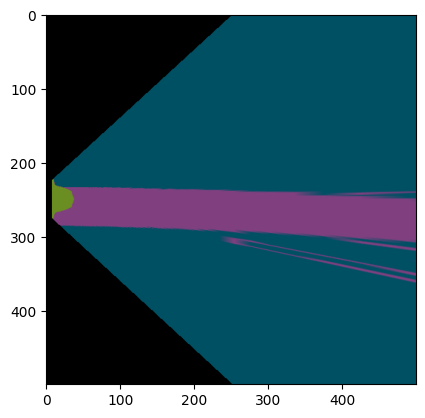

In [287]:
plt.imshow(bev.astype(np.uint8))

In [288]:
filename= "/kaggle/input/front-test/geometric/geometric/front/t_0_0_0001000.png"
image1 = cv2.cvtColor(cv2.imread(filename), cv2.COLOR_BGR2RGB)
image2 = npy2img(files[0])

(604, 964, 3)


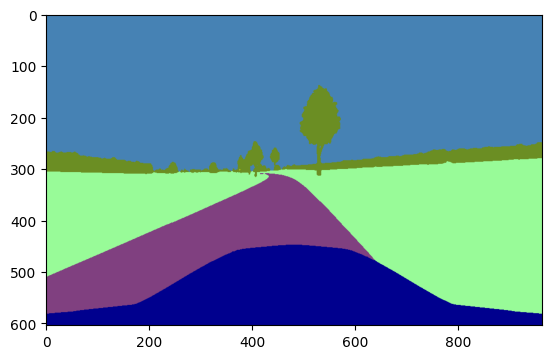

In [289]:
print(image1.shape)
plt.imshow(image1)

(256, 512, 3)


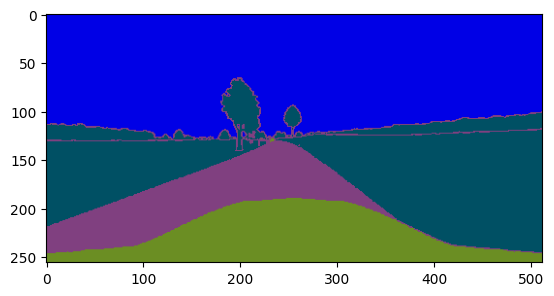

In [290]:
print(image2.shape)
plt.imshow(image2)

In [291]:
print(image1.shape)
print(image2.shape)

(604, 964, 3)
(256, 512, 3)


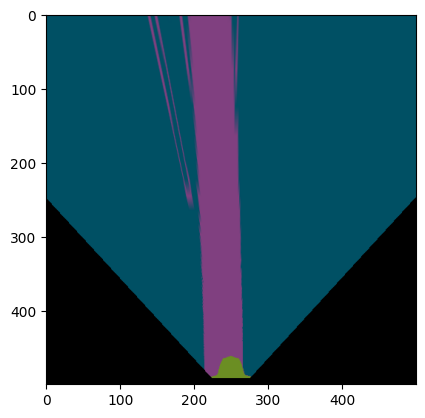

In [292]:
bev_viz = np.transpose(bev, (1, 0, 2))
bev_viz = np.rot90(bev_viz, k=2)
plt.imshow(bev_viz.astype(np.uint8))

In [294]:
h = max(first.shape[0], bev.shape[0])
w = first.shape[1] + bev.shape[1]
out = cv2.VideoWriter('/kaggle/working/output_video.mp4', cv2.VideoWriter_fourcc(*'mp4v'), 5, (w, h))

def pad_to_height(img, target_h):
    h, w = img.shape[:2]
    pad_top = (target_h - h) // 2
    pad_bottom = target_h - h - pad_top
    return np.pad(img, ((pad_top, pad_bottom), (0,0), (0,0)), mode='constant', constant_values=0)

for i,f in enumerate(files[:500]):
    print(i)
    img = npy2img(f)
    pix = perspective(plane.xyz, P, plane.col, plane.row)
    bev = bilinear_sampler(np.copy(img), pix).astype(np.uint8)
    bev_viz = np.transpose(bev, (1, 0, 2))
    bev_viz = np.rot90(bev_viz, k=2)

    img_p = pad_to_height(img, h)
    bev_p = pad_to_height(bev_viz, h)

    concat = np.concatenate((img_p, bev_p), 1)
    out.write(cv2.cvtColor(concat, cv2.COLOR_RGB2BGR))

out.release()

0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
66
67
68
69
70
71
72
73
74
75
76
77
78
79
80
81
82
83
84
85
86
87
88
89
90
91
92
93
94
95
96
97
98
99
100
101
102
103
104
105
106
107
108
109
110
111
112
113
114
115
116
117
118
119
120
121
122
123
124
125
126
127
128
129
130
131
132
133
134
135
136
137
138
139
140
141
142
143
144
145
146
147
148
149
150
151
152
153
154
155
156
157
158
159
160
161
162
163
164
165
166
167
168
169
170
171
172
173
174
175
176
177
178
179
180
181
182
183
184
185
186
187
188
189
190
191
192
193
194
195
196
197
198
199
200
201
202
203
204
205
206
207
208
209
210
211
212
213
214
215
216
217
218
219
220
221
222
223
224
225
226
227
228
229
230
231
232
233
234
235
236
237
238
239
240
241
242
243
244
245
246
247
248
249
250
251
252
253
254
255
256
257
258
259
260
261
262
263
264
265
266
267
268
269
270
271
272
273
274
275
276
27